# HT-CapsNet output analysis

Every notebook in `notebooks/model_analysis/` renders the same eleven sections, in
the same order, from the same code in `notebooks/utils/hcast_analysis_utils.py`, so
a section of one family's notebook can be read directly against the same section of
another's. Shared objective names come from `FAMILY_PROFILES`, while each notebook
defines its own editable `BASELINE_BY_DATASET` and `MANUAL_RUNS` lists.

Where a section comes out shorter for one family, that is a fact about the family
rather than a difference in what was asked for: the code drops a loss term the runs
never logged, a diagnostic panel that no selected run moved off zero, and a
gradient-support block the architecture does not contain. Each of those prints a
line saying which and why.

## Setup

In [31]:
from pathlib import Path
import sys

import numpy as np

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir()), cwd)
notebook_utils_dir = repo_root / 'notebooks' / 'utils'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

import thesis_style
import hcast_analysis_utils as hu
from hcast_analysis_utils import HCastAnalysis, resolve_project_root, show_markdown

# The one line that differs between the five model-analysis notebooks.
FAMILY = 'ht_capsnet'

# Which decoders every figure and table below shows: 'both', 'independent' or
# 'topdown'. The two decoders do not select the same epoch, so 'both' is the
# default; the other two read the whole page for one decoder and halve the
# curves in every panel. Individual calls can still override it with
# `decoder_view=`.
DECODER_VIEW = hu.set_decoder_view('both')

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')

# Figures are runtime artifacts, so they live under /scratch, not in the repo.
# Copy the PDFs into images/ht_capsnet/ of the thesis tree when including them.
FIGURE_DIR = hu.set_figure_dir(OUTPUTS_ROOT / 'analysis' / 'model_analysis' / FAMILY / 'figures')

print(f'Project root: {PROJECT_ROOT}')
print(f'Family:       {hu.FAMILY_PROFILES[FAMILY].display_name}')
print(f'Decoders:     {hu.decoder_view_phrase()} decoding')
print(f'Figures:      {FIGURE_DIR}')

Project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study
Family:       HT-CapsNet
Decoders:     top-down and independent decoding
Figures:      /scratch/g.saggini1/outputs/analysis/model_analysis/ht_capsnet/figures


## Run matrix

Choose the runs shown by editing `BASELINE_BY_DATASET` and `MANUAL_RUNS` below.
Every directory and label is local and explicit, so entries can be freely added,
removed, renamed or restricted to individual datasets.

A configured arm with no readable seed directory - not launched yet, or renamed
since the profile was written - is named explicitly rather than dropped silently,
so "this family has no such arm" stays distinguishable from "its arm is not on
disk". The gradient-block report that follows states which blocks the logs actually
carry and flags any run whose config selects a block its logs do not have.

In [32]:
INCLUDE_BASELINES = True
BASELINE_BY_DATASET = {
    'cifar-100': {'run_dir': 'capsnet_cifar100', 'label': 'HT-CapsNet baseline (dynamic weights)'},
    'cub-200-2011': {'run_dir': 'capsnet_cub200', 'label': 'HT-CapsNet baseline (dynamic weights)'},
    'fgvc-aircraft': {'run_dir': 'capsnet_aircraft', 'label': 'HT-CapsNet baseline (dynamic weights)'},
}
MANUAL_RUNS = [
    {'run_dir': 'capsnet_cifar100_hcc', 'label': 'HT-CapsNet + HCC (exploratory)'},
    {'run_dir': 'capsnet_cub200_hcc', 'label': 'HT-CapsNet + HCC (exploratory)'},
    {'run_dir': 'capsnet_aircraft_hcc', 'label': 'HT-CapsNet + HCC (exploratory)'},
    
    {'run_dir': 'ht_capsnet_cifar100_lex_coarse_first', 'label': 'HT-CapsNet lex coarse-first (unit weights)'},
    {'run_dir': 'ht_capsnet_cub200_lex_coarse_first', 'label': 'HT-CapsNet lex coarse-first (unit weights)'},
    {'run_dir': 'ht_capsnet_aircraft_lex_coarse_first', 'label': 'HT-CapsNet lex coarse-first (unit weights)'},
]

analysis = HCastAnalysis.for_family(
    FAMILY, OUTPUTS_ROOT, include_baselines=INCLUDE_BASELINES,
    baseline_by_dataset=BASELINE_BY_DATASET, manual_runs=MANUAL_RUNS,
)
analysis.print_run_summary()
print()
analysis.report_gradient_blocks()

Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_cifar100_hcc
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_cub200_hcc
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_aircraft_hcc
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/ht_capsnet_cub200_lex_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/ht_capsnet_aircraft_lex_coarse_first
Baseline-only datasets (no selected comparison runs): cub-200-2011, fgvc-aircraft
5 configured run(s) have no readable seed directory and are absent from every figure below:
    capsnet_cifar100_hcc
    capsnet_cub200_hcc
    capsnet_aircraft_hcc
    ht_capsnet_cub200_lex_coarse_first
    ht_capsnet_aircraft_lex_coarse_first
[cifar-100] HT-CapsNet baseline (dynamic weights): epochs=100, best_td_epoch=51.0, best_ind_epoch=51.0, baseline, seeds=[0, 1]
[cifar-100] HT-CapsNet lex coarse-first (unit weights): epochs=6, best_td_epoch=6.0, bes

## Validation curves

FPA and weighted AP are higher-is-better; AHD and TICE are lower-is-better, and the
arrow in the test table below repeats that. Colour is the run and line style is the
decoder: solid is independent decoding, dashed is top-down. The band is one standard
deviation across seeds and is drawn only where more than one seed contributed. The
marker on each curve is that run's selected checkpoint *for that decoder* - the two
decoders do not in general select the same epoch, which is why every comparison
below keeps them apart.

Both decoders are drawn even where one is degenerate by construction - TICE is
identically zero under top-down decoding, because top-down decoding is what makes the
path consistent - since seeing that zero is how a reader confirms the decoder did what
it claims.

**CIFAR-100: validation metrics (top-down and independent decoding)**

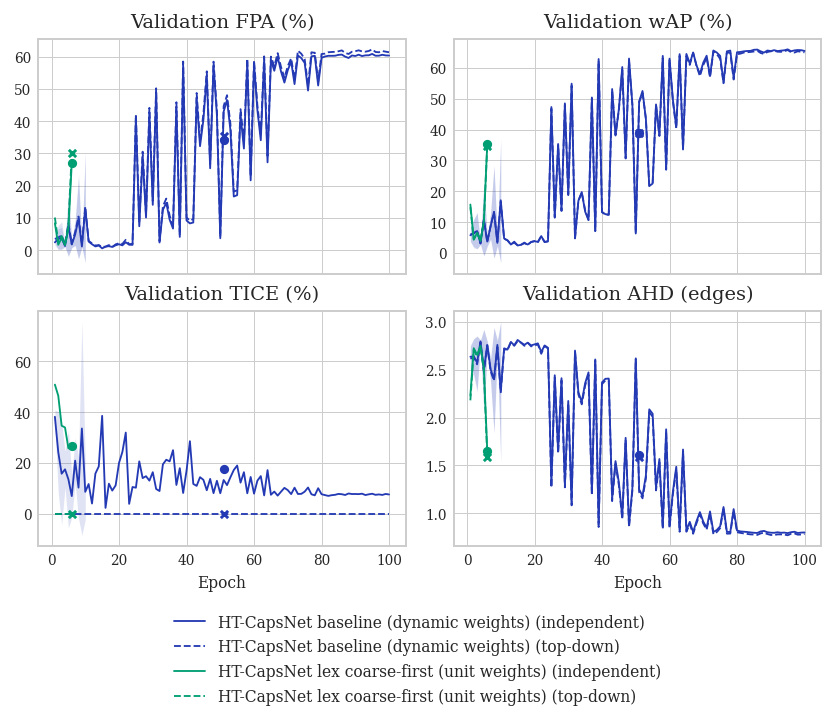

**CUB-200: validation metrics (top-down and independent decoding)**

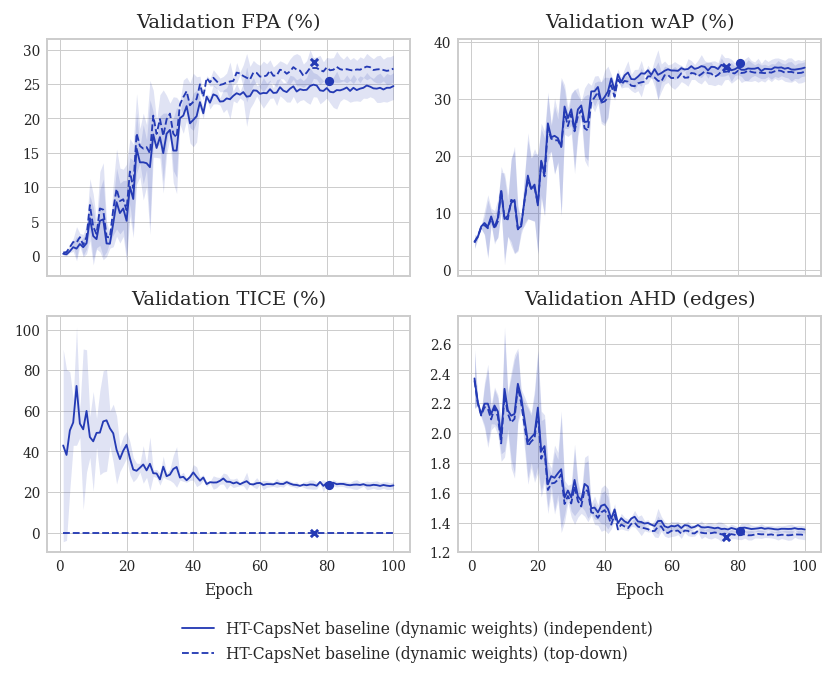

**Aircraft: validation metrics (top-down and independent decoding)**

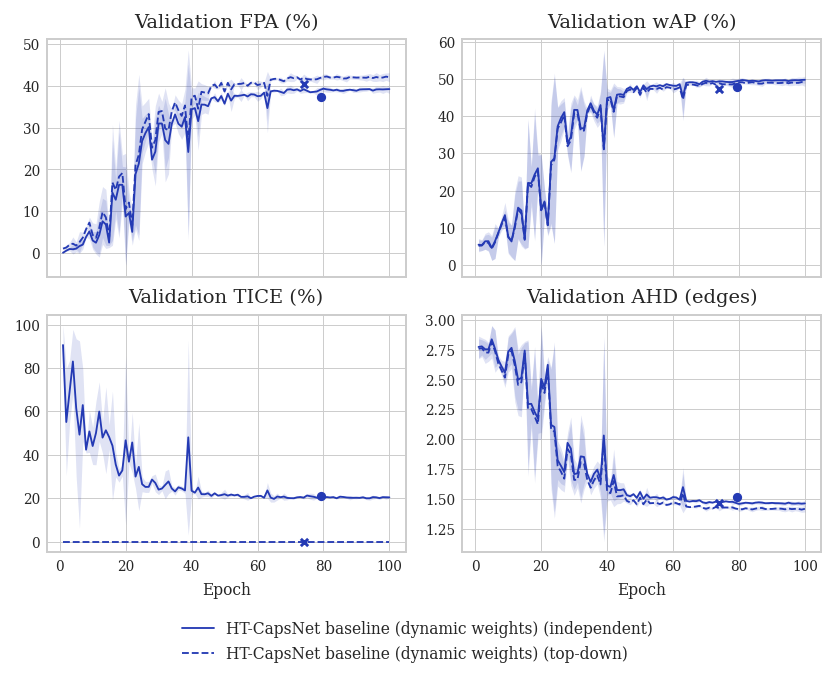

In [33]:
analysis.plot_validation_curves()

## Per-level validation accuracy

The same runs resolved by hierarchy level, coarsest panel first. Read against the
FPA panel above, this separates a run that gained fine accuracy from one that gained
full-path accuracy by repairing its coarse predictions.

In the coarsest panel the two decoder lines coincide exactly, because top-down decoding
starts at that level and cannot differ from independent decoding there. They are drawn
anyway: the coincidence is the check that the top-down decoder is anchored where it
should be, and the deeper panels are where the two separate.

**CIFAR-100: per-level validation accuracy**

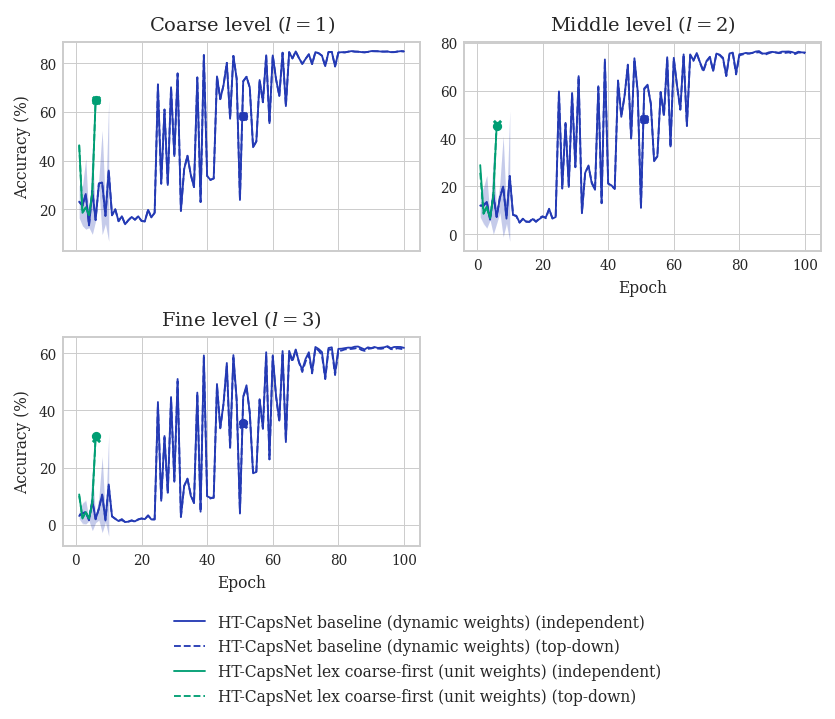

**CUB-200: per-level validation accuracy**

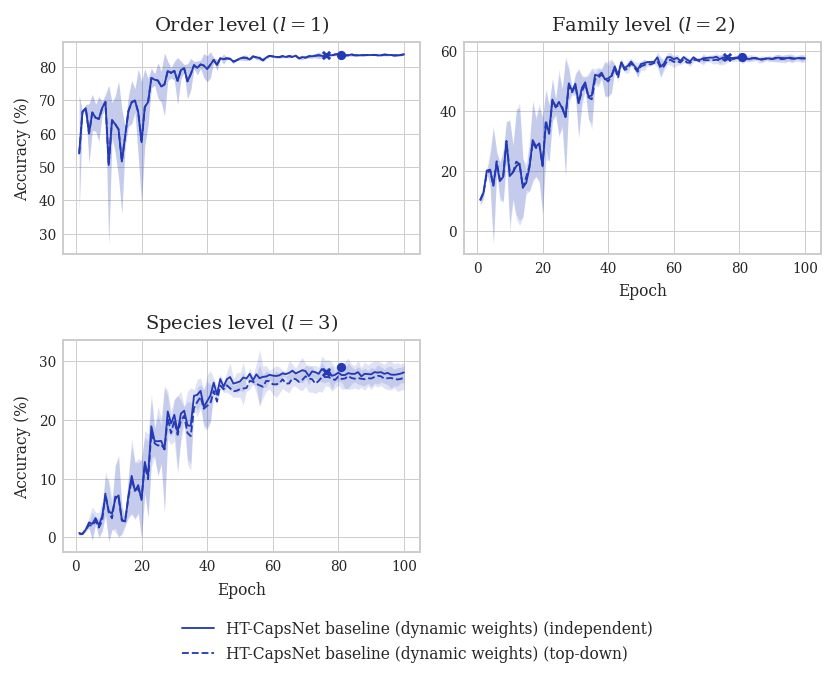

**Aircraft: per-level validation accuracy**

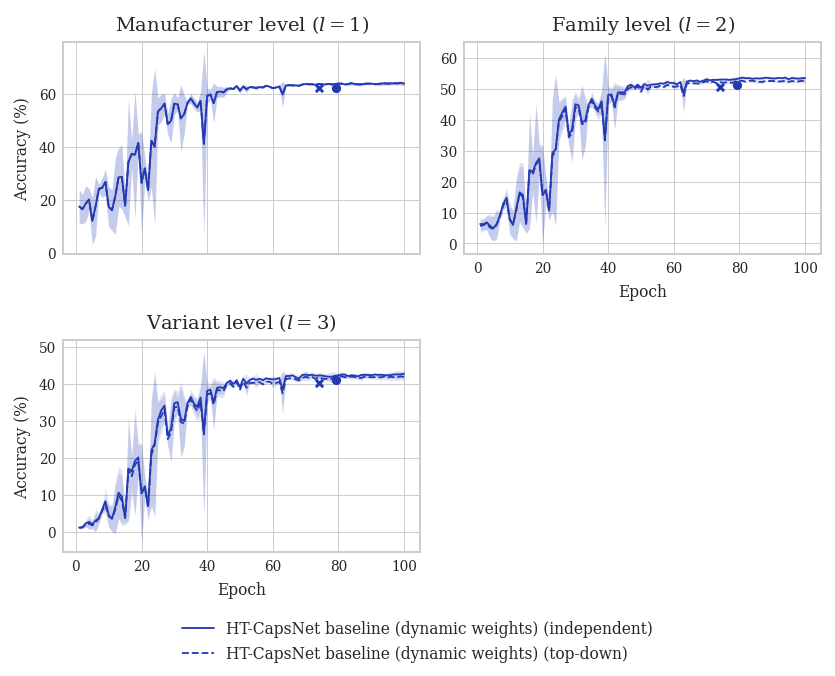

In [34]:
analysis.plot_per_level_validation_accuracy()

## Final selected-checkpoint level accuracy

The three datasets are shown in one row. Points are independent-decoding test
accuracy means at the independently selected checkpoint, error bars are one
sample standard deviation across seeds, and lines connect hierarchy levels
within the same run. The vertical axis is shared and adapts to the visible values and error bars.

**Final selected-checkpoint level accuracy (independent decoding)**

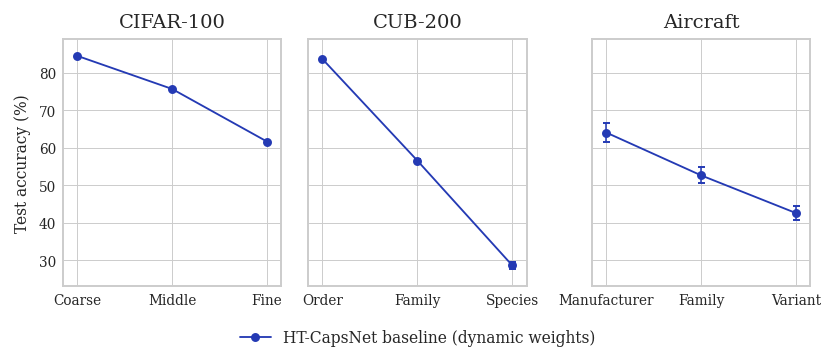

In [35]:
analysis.plot_final_level_test_accuracy(decoder_view='independent')

## Training losses

Two figures: the terms of the aggregate objective, then the per-level terms. The
terms plotted are the ones the family profile names, minus any the selected runs
never logged; two keys that are aliases of a single quantity collapse to one panel.

A family whose objective does not decompose into per-level terms has no second
figure here, and says so - for HRN that is the difference between the plain
baseline and the `level_marginal` arms.

**CIFAR-100: terms of the training objective**

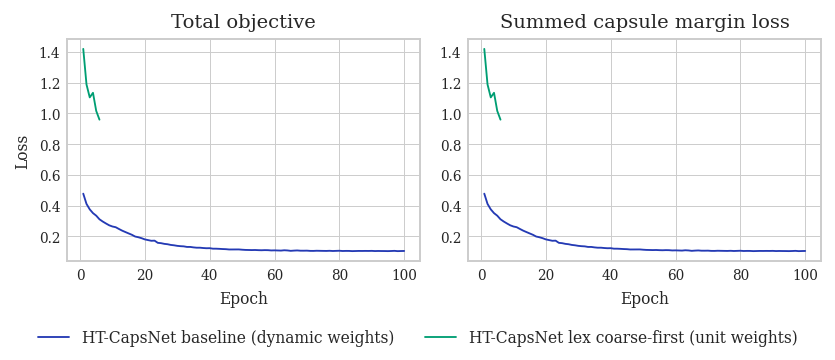

**CIFAR-100: per-level training objectives**

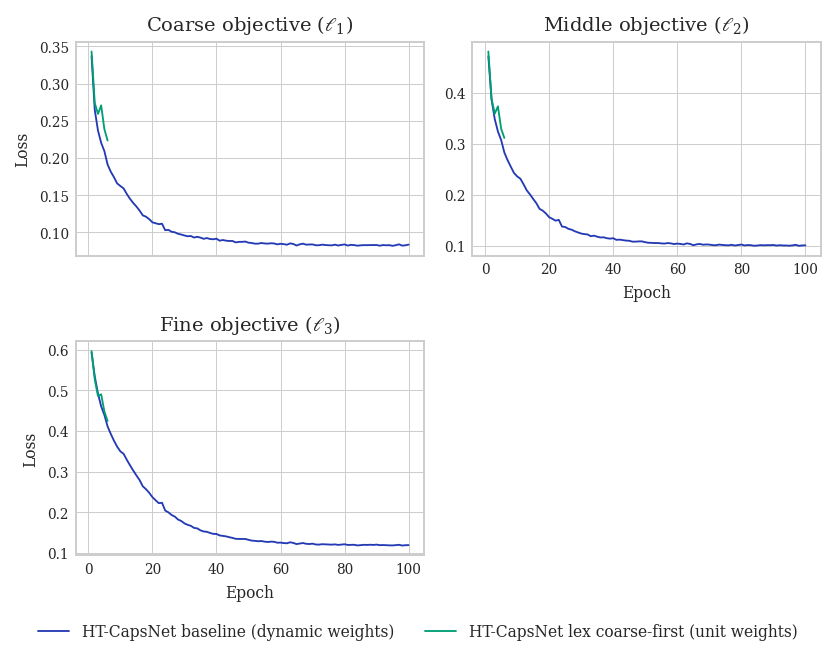

**CUB-200: terms of the training objective**

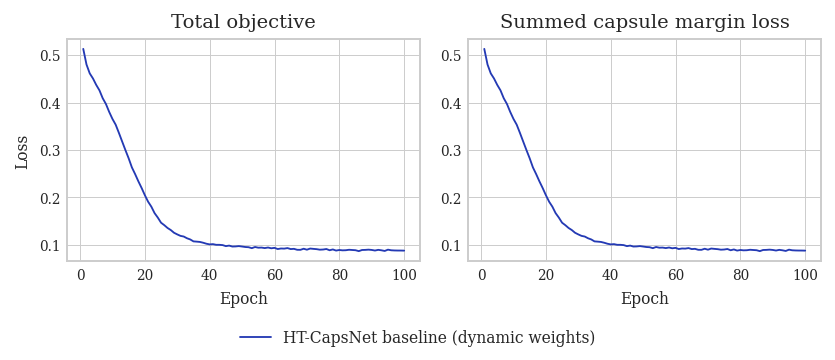

**CUB-200: per-level training objectives**

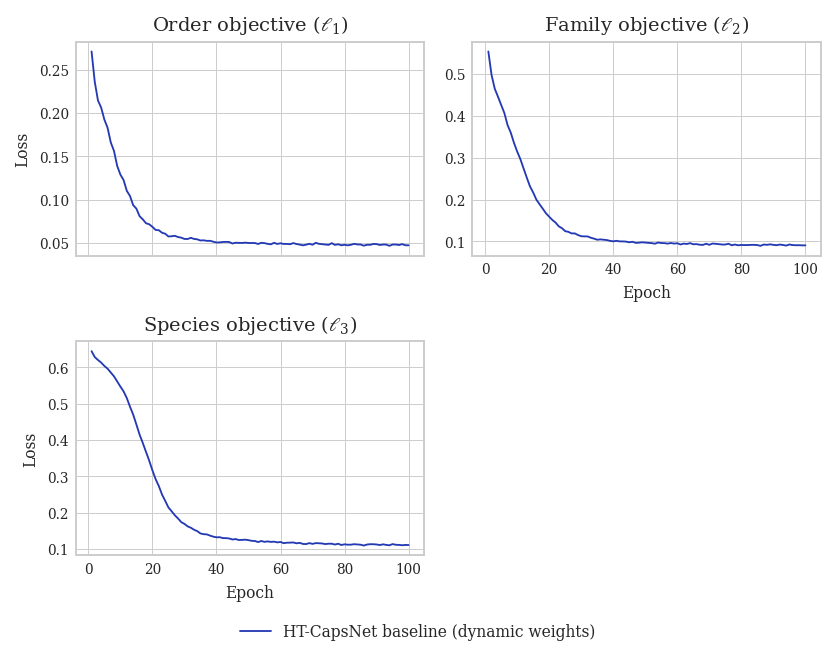

**Aircraft: terms of the training objective**

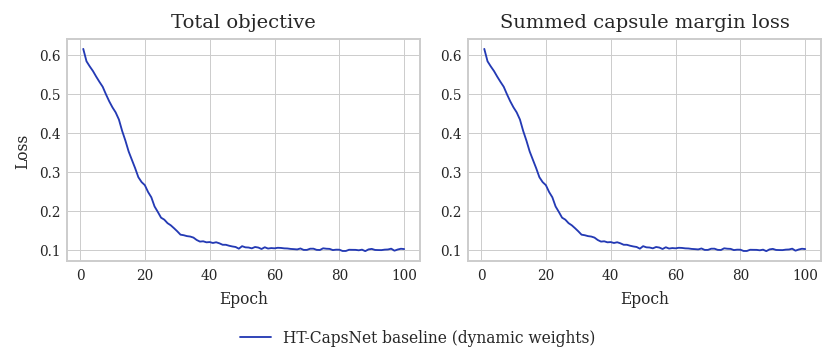

**Aircraft: per-level training objectives**

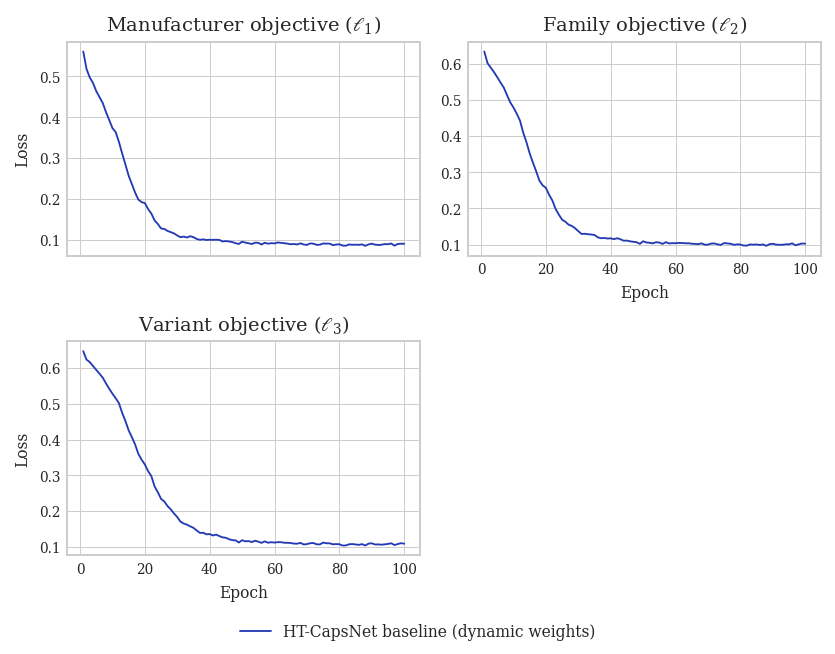

In [36]:
analysis.plot_training_losses()

## Effective level-loss weights

The weight each level objective actually carried, epoch by epoch. Only some families
weight their level losses and those that do can weight them dynamically, so a
comparison between two arms with different `weight_mode` mixes the mechanism under
test with a change in level weighting; this section is what makes that second
variable explicit rather than implicit.

One caveat when reading a lexicographic arm: the lexicographic step is rebuilt from
the per-level gradients, so check whether the logged weight still scales the applied
update for this family before reading a difference here as causal. A family that
logs no weights prints a line and the section stays empty.

**CIFAR-100: effective level-loss weights**

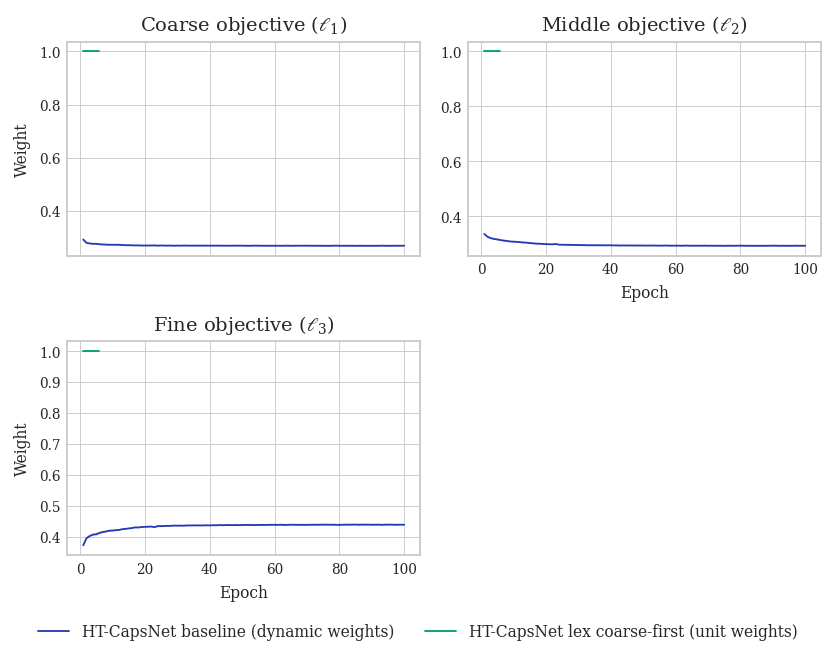

**CUB-200: effective level-loss weights**

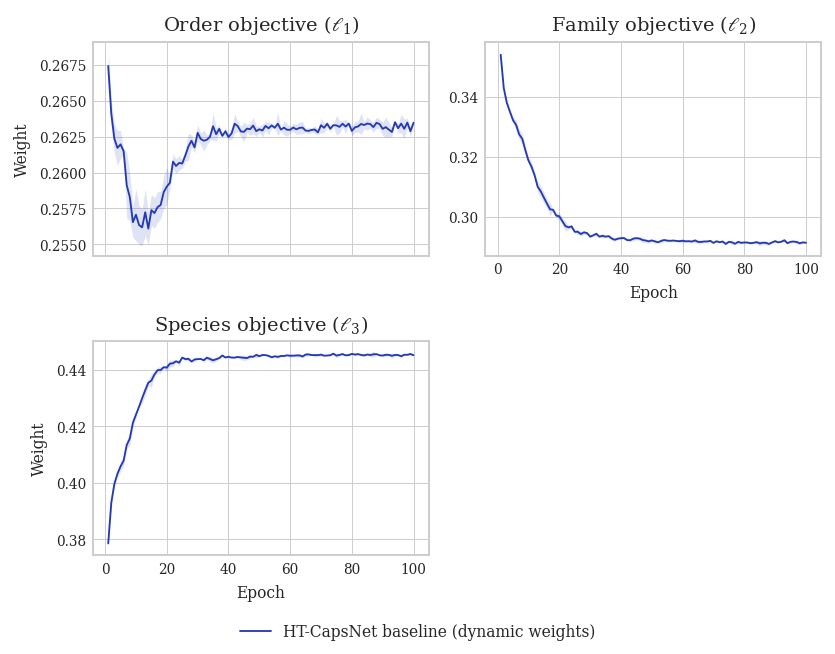

**Aircraft: effective level-loss weights**

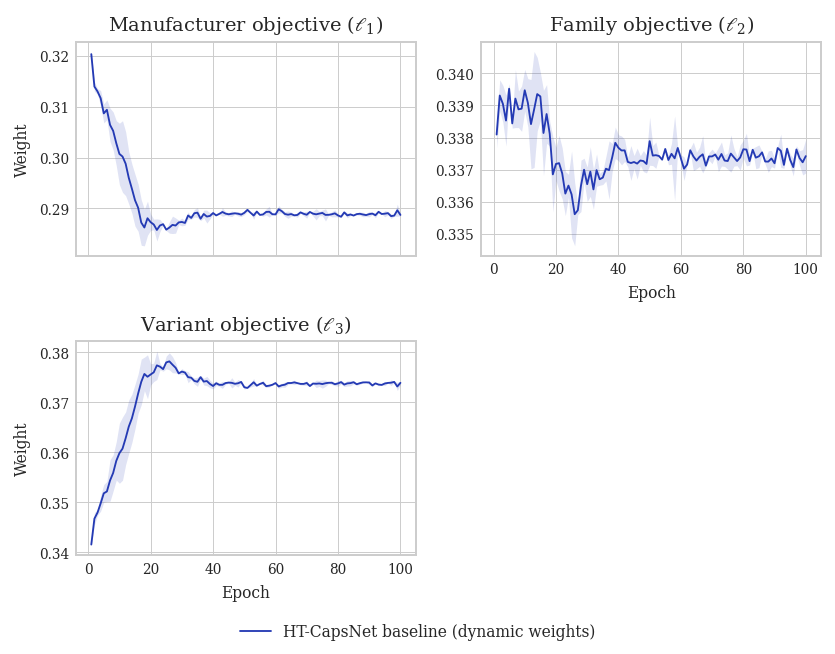

In [37]:
analysis.plot_level_loss_weights()

## Level objectives within each run

The previous section compares one objective across runs; this one keeps the levels
of a single run together in one panel, which is where a run that trades shallow loss
for deep loss becomes visible.

**CIFAR-100: level objectives within each run**

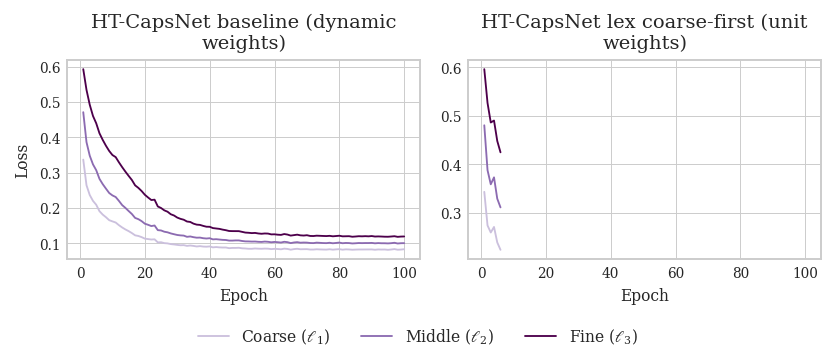

**CUB-200: level objectives within each run**

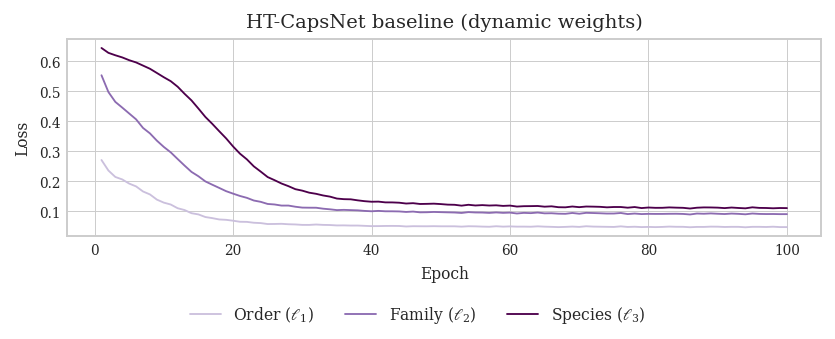

**Aircraft: level objectives within each run**

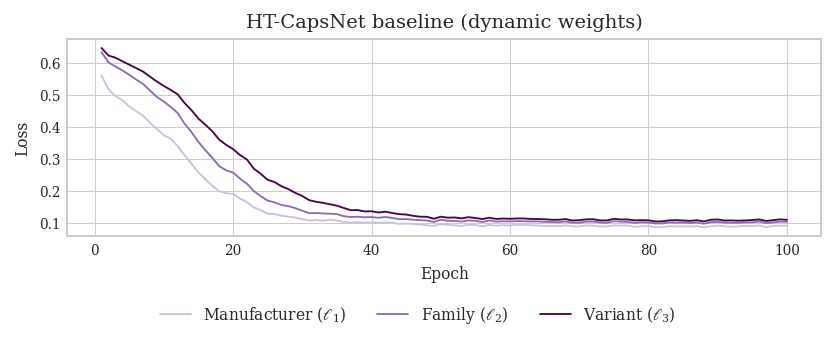

In [38]:
analysis.plot_per_run_per_level_training_losses()

## Gradient and parameter diagnostics

Up to five figures, all indexed by exact gradient-support block rather than by a
family's own parameter names, because which blocks exist is a property of the
architecture: H-CAST branches fine-to-coarse and has $P_{123}$/$P_{12}$/$P_1$,
HT-CapsNet runs the reverse cascade and has $P_{123}$/$P_{23}$/$P_3$, HRN and
Hier-COS share one trunk and have $P_{123}$ alone. A shorter figure here is the
architecture, not a missing measurement.

The last two figures - projected cosines against their own pre-projection values,
and the projection steps skipped for numerical safety - exist only for runs trained
with `train.lexicographic.enabled`, and the section says so when none were
selected.

[CIFAR-100] projection steps performed at every epoch:
[CIFAR-100]     HT-CapsNet lex coarse-first (unit weights): P₁₂₃ middle against coarse; P₁₂₃ fine against higher-priority


**CIFAR-100: level gradient norms on the shared blocks**

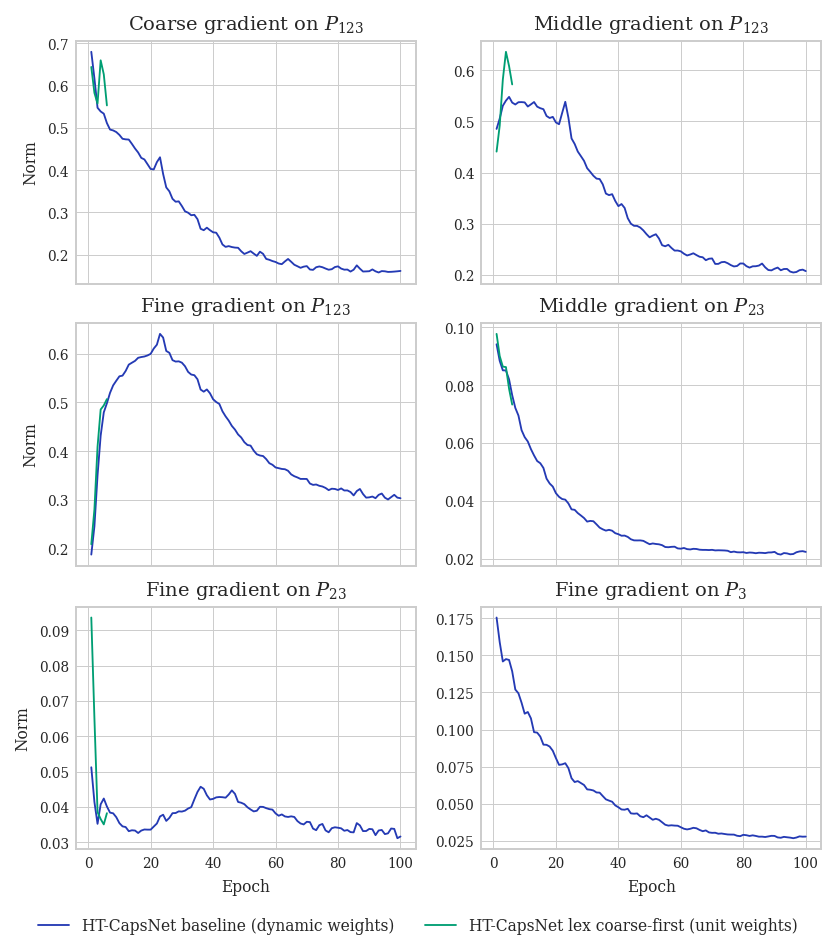

**CIFAR-100: pairwise gradient alignment**

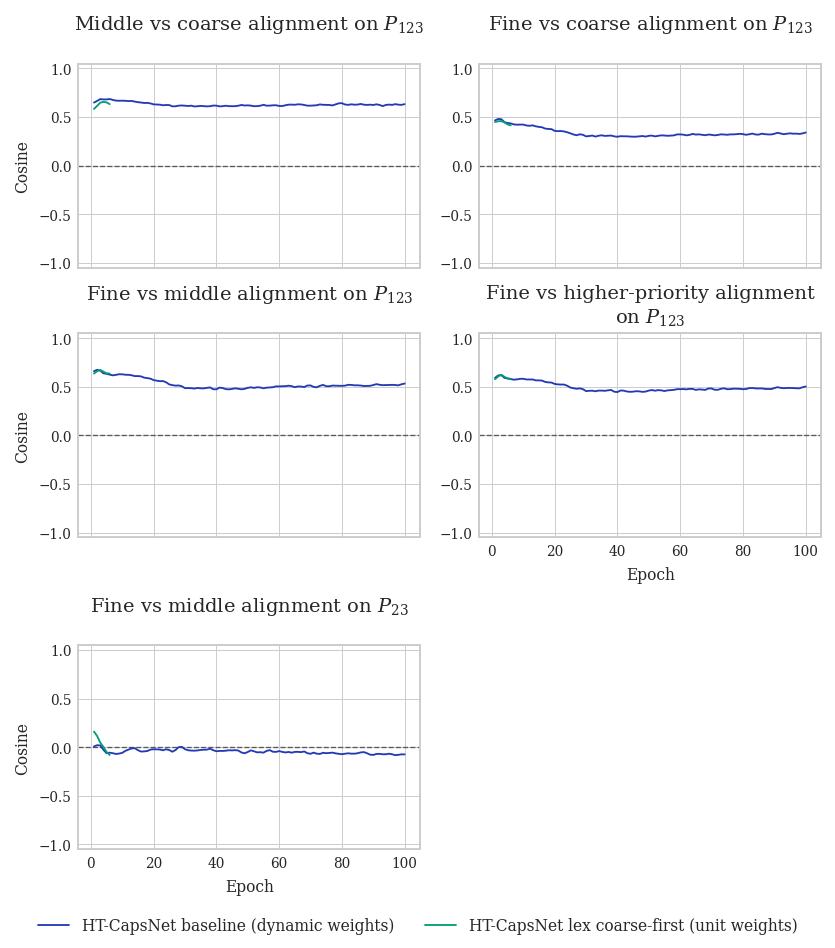

**CIFAR-100: parameter scale and per-epoch movement**

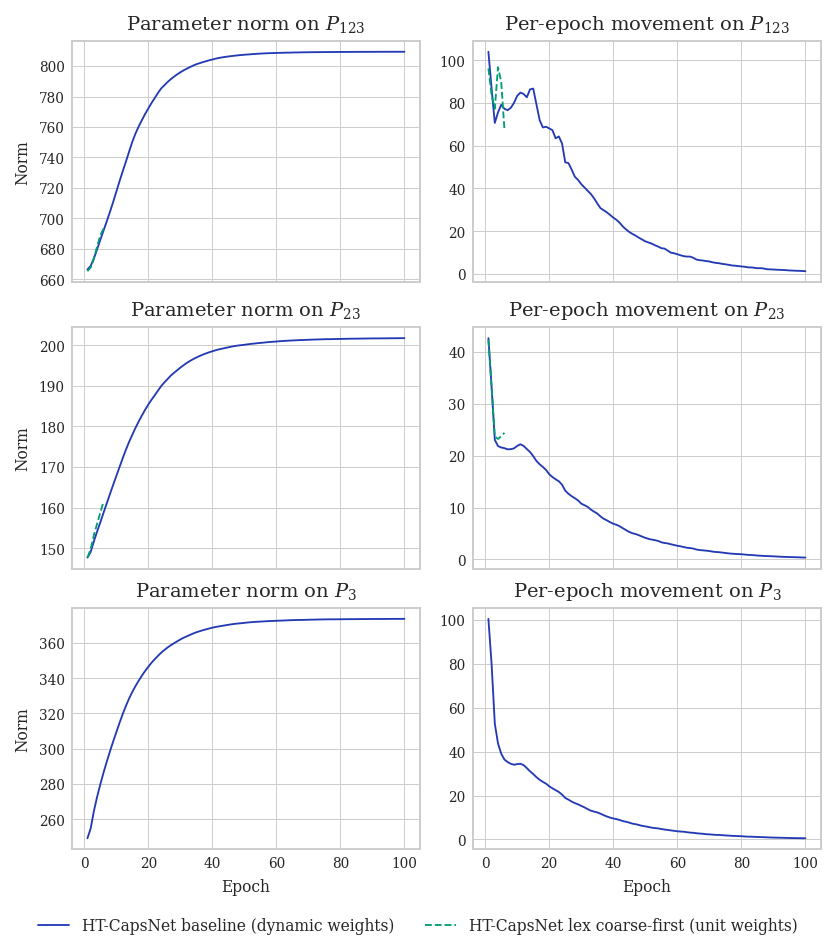

**CIFAR-100: gradient alignment before and after projection**

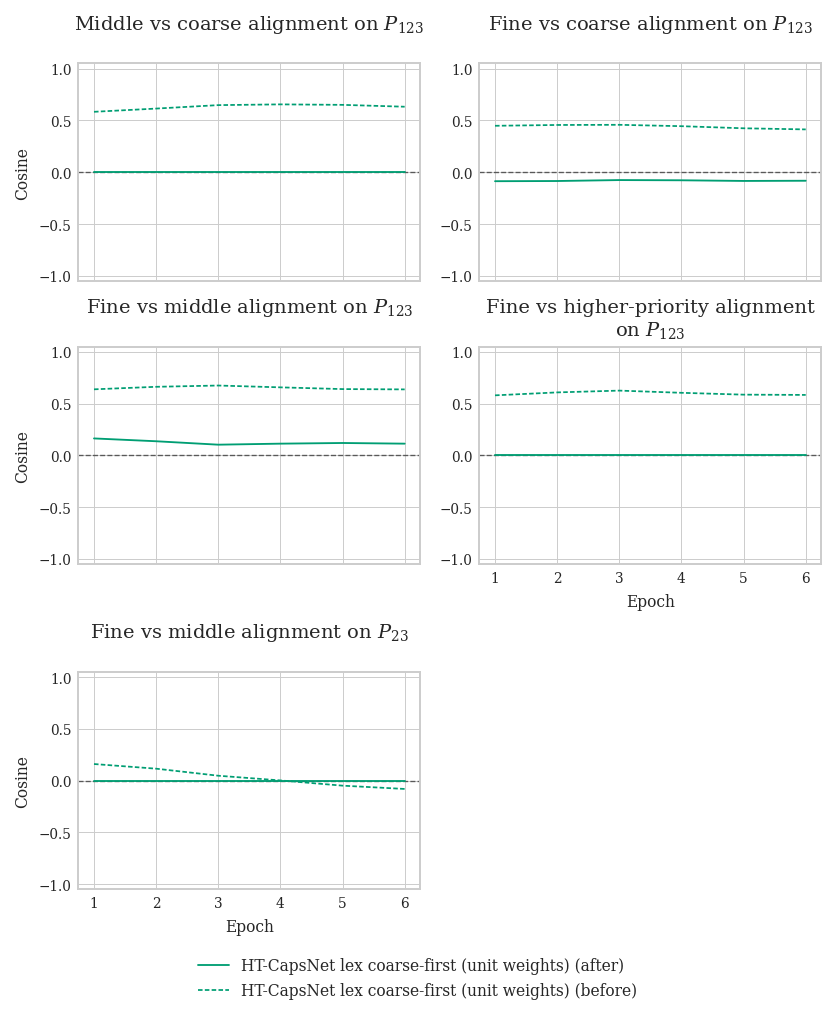

**CUB-200: level gradient norms on the shared blocks**

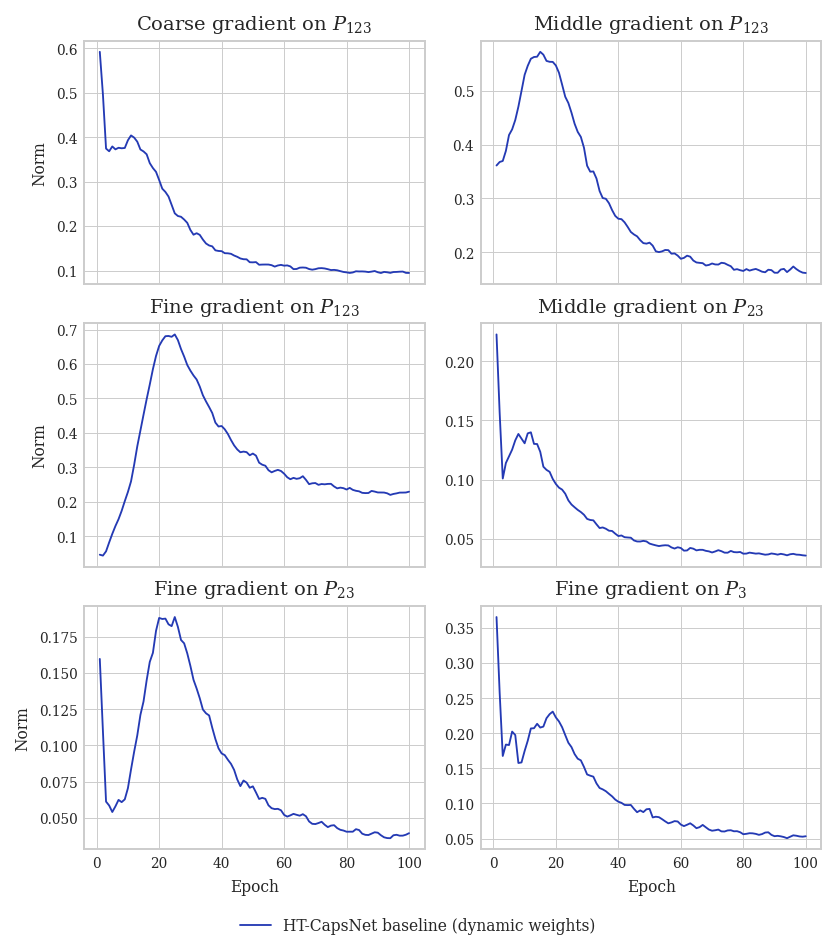

**CUB-200: pairwise gradient alignment**

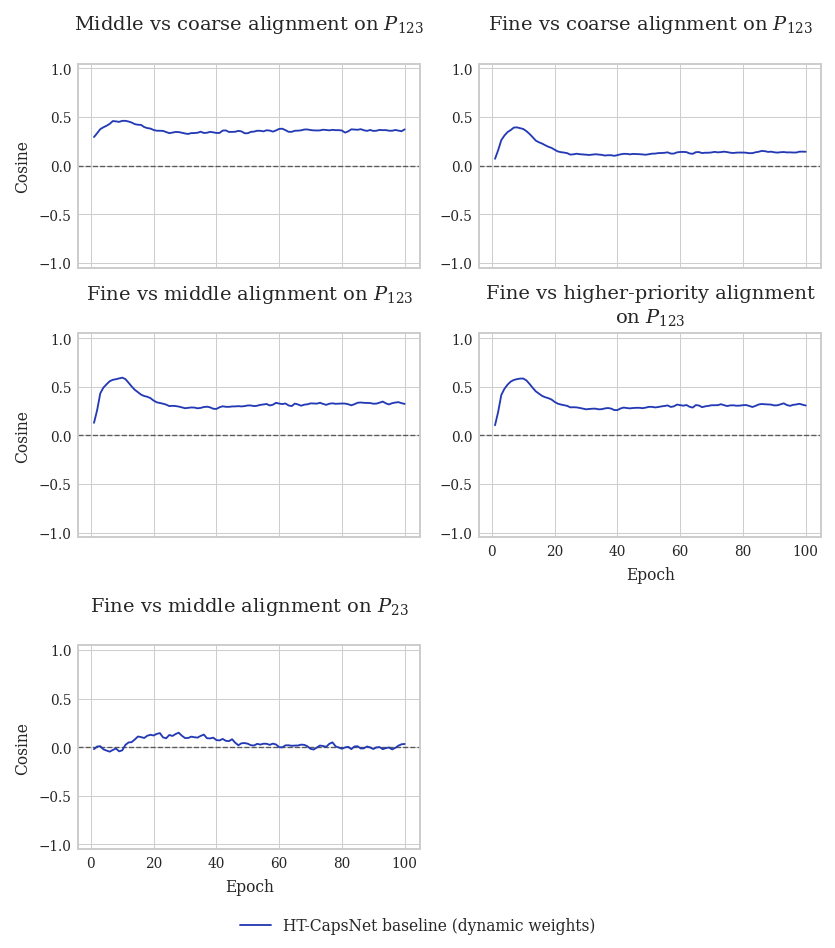

**CUB-200: parameter scale and per-epoch movement**

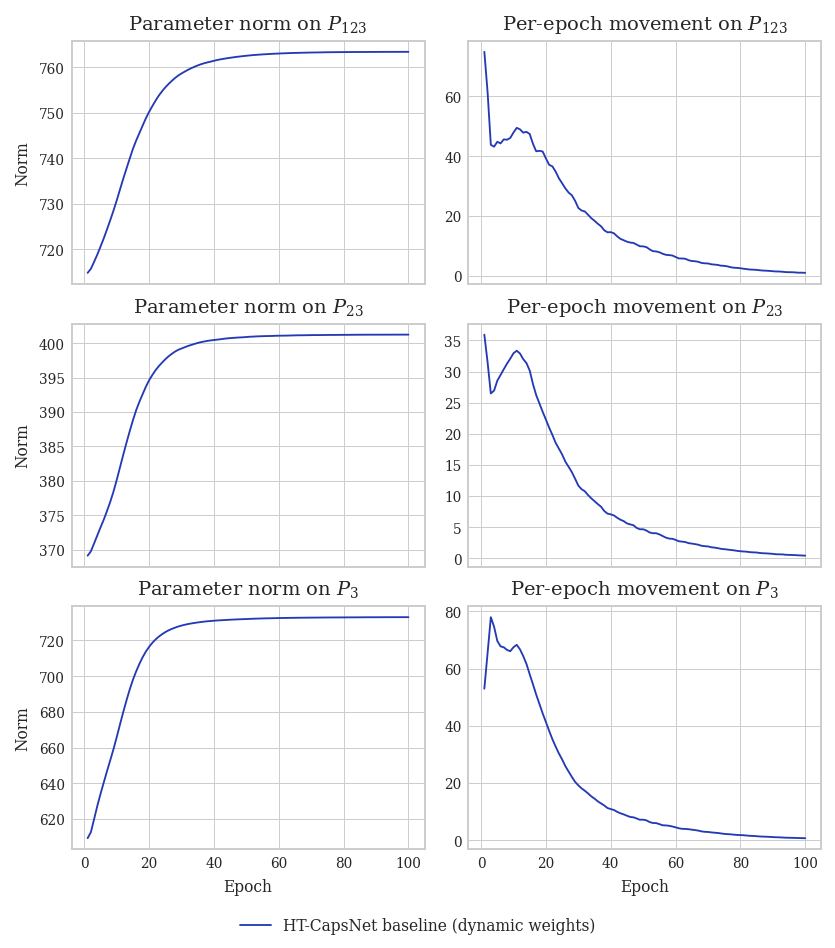

[CUB-200] no post-projection diagnostics: none of the selected runs were trained with train.lexicographic.enabled.


**Aircraft: level gradient norms on the shared blocks**

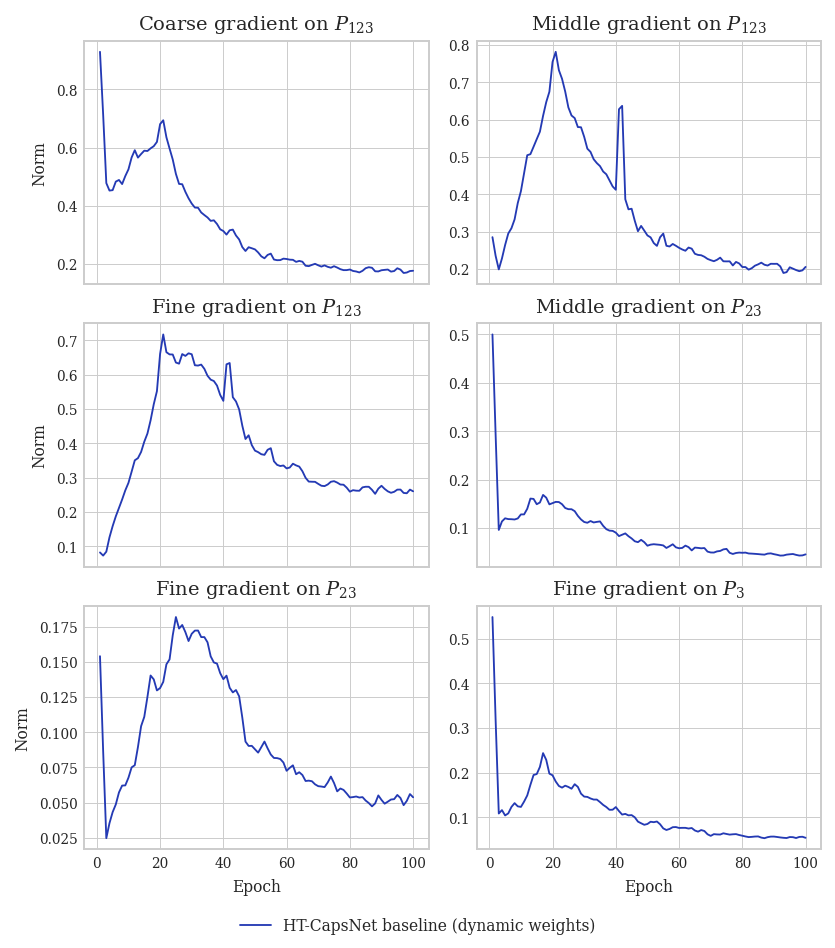

**Aircraft: pairwise gradient alignment**

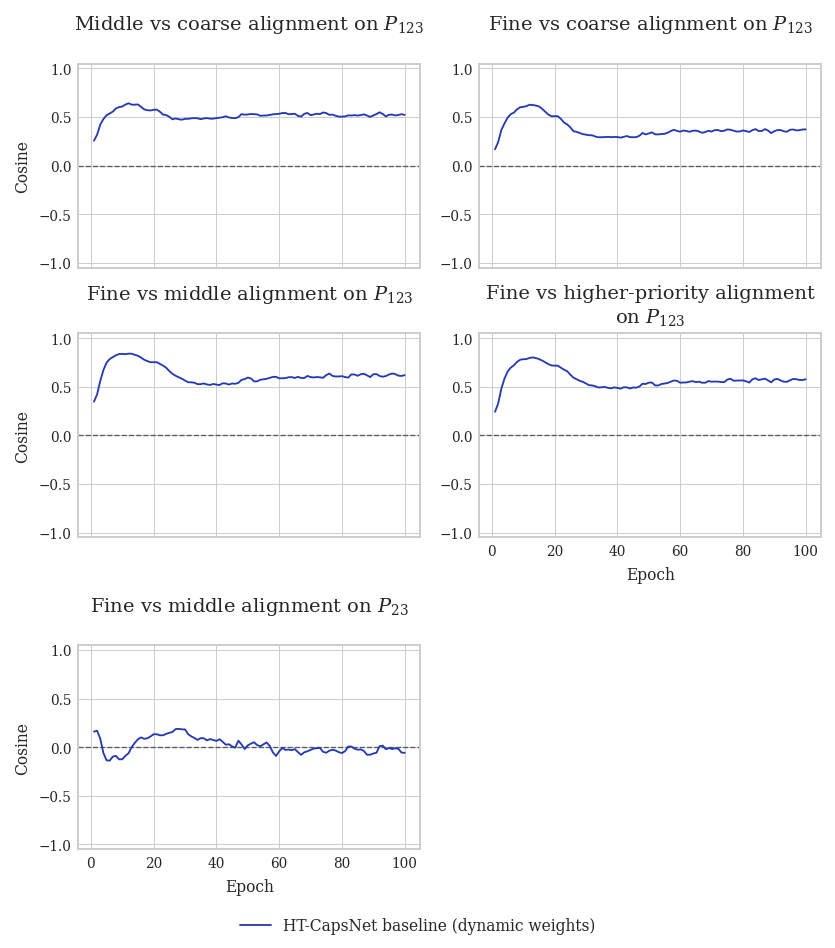

**Aircraft: parameter scale and per-epoch movement**

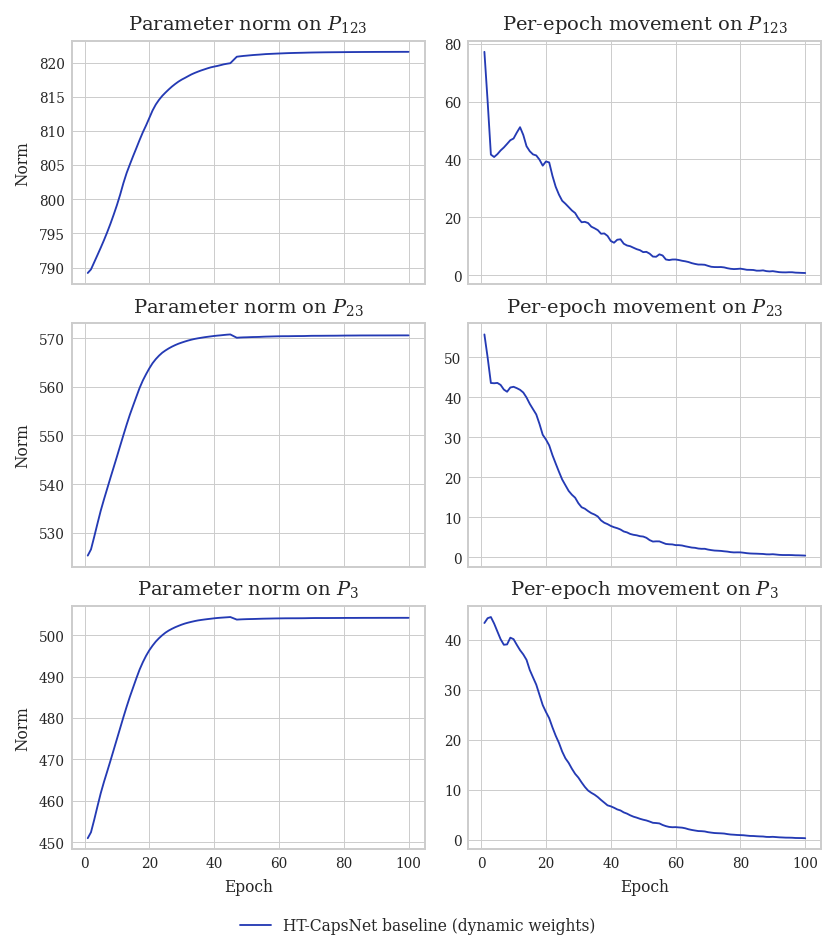

[Aircraft] no post-projection diagnostics: none of the selected runs were trained with train.lexicographic.enabled.


In [39]:
analysis.plot_gradient_diagnostics()

## Output-space constraint diagnostics

One shared panel list for every family, `MECHANISM_DIAGNOSTIC_SPECS`, filtered three
ways so that what survives is what carries information. A panel is dropped when no
selected run logs the key at all; when its value is the same constant in every run,
in which case the constant is named, so "held at 1" confirms a binary switch was on
for the whole run without spending a panel on a flat line; and when it traces the
identical curve to a panel already on the page, in which case that panel is named.

The last of those is what removes the "after" panels on a family whose mechanism never
ran, since nothing rewrote the scores and "after" is a copy of "before", and the
residual reduction on one that did, since the post-projection residual sits at
numerical zero and the reduction is therefore the residual before it. What is left is
the set of quantities some mechanism actually moved, which makes the panel count
itself a readout of whether it fired.

The trailing panels are structural rather than mechanistic and are present for every
family: how much fine probability mass sits under the true parent, where the true
class ranks among its siblings, how often the parent is correct, and how accurate
the fine level is when it is. Those describe the hierarchy a run learned whether or
not any output-space correction was applied to it.

[CIFAR-100] constant in every selected run, so not plotted: Total fine probability shift (held at 0); True-class fine probability shift (held at 0); Fine prediction flip rate (held at 0).
[CIFAR-100] duplicates a panel already on this page, so not plotted: Fine mass under the true parent, after (identical to Fine mass under the true parent, before); True-class rank among siblings, after (identical to True-class rank among siblings, before).


**CIFAR-100: output-space constraint diagnostics**

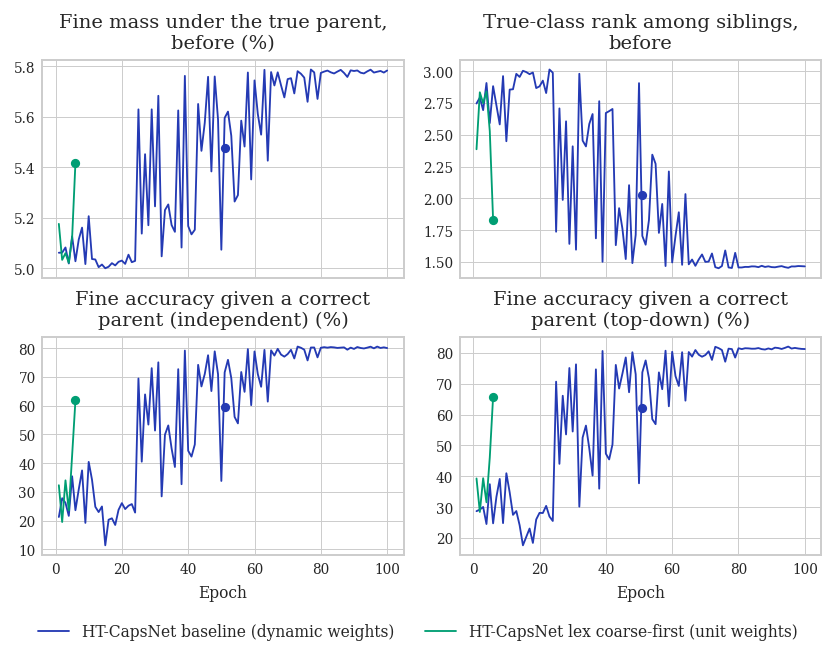

[CUB-200] constant in every selected run, so not plotted: Total fine probability shift (held at 0); True-class fine probability shift (held at 0); Fine prediction flip rate (held at 0).
[CUB-200] duplicates a panel already on this page, so not plotted: Fine mass under the true parent, after (identical to Fine mass under the true parent, before); True-class rank among siblings, after (identical to True-class rank among siblings, before).


**CUB-200: output-space constraint diagnostics**

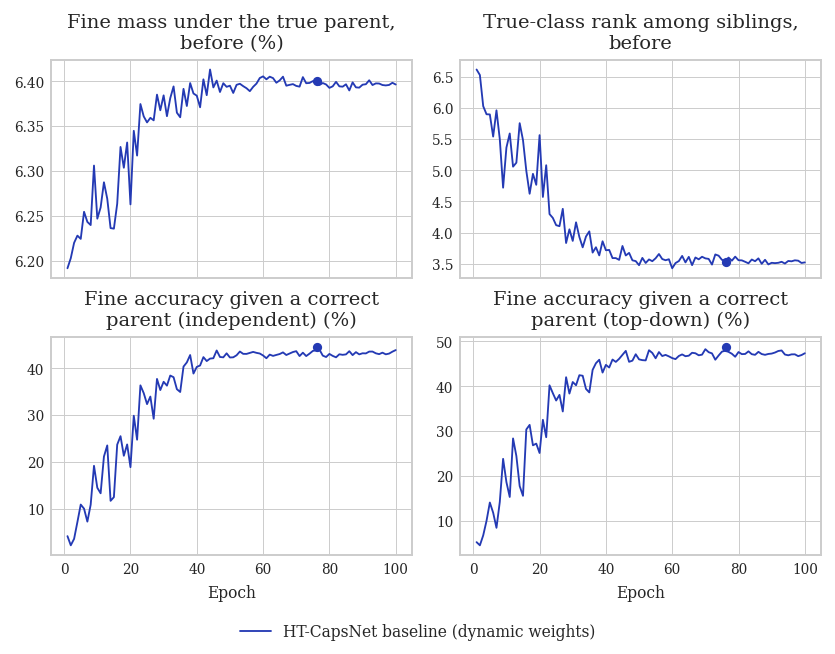

[Aircraft] constant in every selected run, so not plotted: Total fine probability shift (held at 0); True-class fine probability shift (held at 0); Fine prediction flip rate (held at 0).
[Aircraft] duplicates a panel already on this page, so not plotted: Fine mass under the true parent, after (identical to Fine mass under the true parent, before); True-class rank among siblings, after (identical to True-class rank among siblings, before).


**Aircraft: output-space constraint diagnostics**

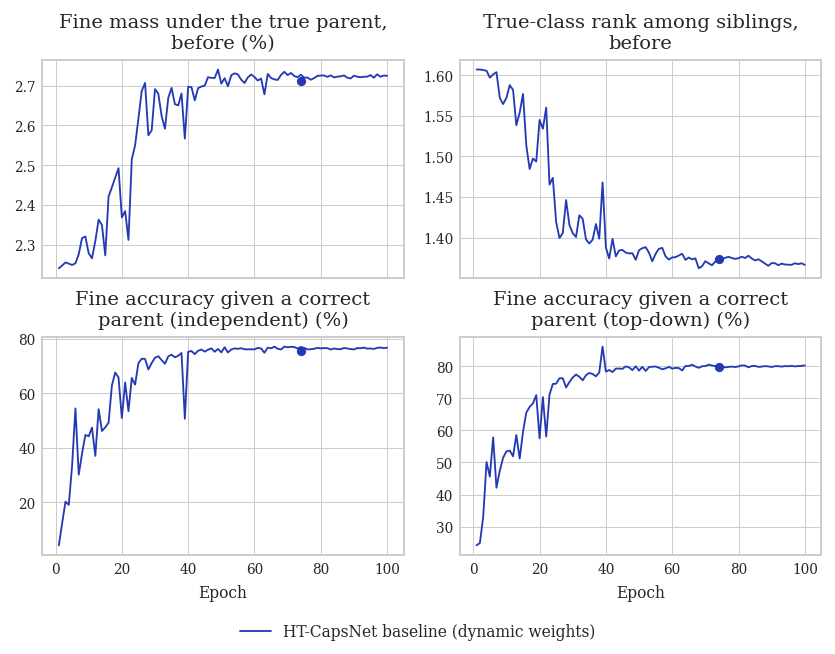

In [40]:
analysis.plot_projection_diagnostics()

## Final selected-checkpoint test tables

Test metrics read from `test_metrics.yaml`, each row at the checkpoint selected for
its own decoder: top-down rows use the top-down-selected checkpoint and independent
rows the independent-selected one. Cells are mean ± standard deviation over the
seeds named in the run matrix; deltas against the baseline are in percentage points
for percentages and in edges for AHD. The best value in a row is bold and the second
best underlined, and a dataset with a single run reports absolute values only.

Two rows are degenerate by construction rather than by accident of these runs, and are
tabulated anyway because the identity is worth showing: TICE under top-down decoding is
zero, because that decoder enforces consistency, and full-path accuracy under top-down
decoding equals the fine-level accuracy, because a correct leaf there implies a correct
path. A value that departs from either is a bug, not a result.

In [41]:
analysis.show_final_test_tables(allow_single_run=True)

### Dataset: `cifar-100`
Baseline run: **HT-CapsNet baseline (dynamic weights)**

| Metric | HT-CapsNet baseline (dynamic weights) (n=2) | HT-CapsNet lex coarse-first (unit weights) (n=1) |
|---|---:|---:|
| Best epoch (TD/Ind) | 95/95 | n/a/n/a |
| FPA (independent) ↑ | **59.93%** | n/a |
| FPA (top-down) ↑ | **61.00%** | n/a |
| wAP (independent) ↑ | **65.27%** | n/a |
| wAP (top-down) ↑ | **64.73%** | n/a |
| TICE (independent) ↓ | **7.53%** | n/a |
| TICE (top-down) ↓ | **0.00%** | n/a |
| AHD (independent) ↓ | **0.808** | n/a |
| AHD (top-down) ↓ | **0.790** | n/a |
| Coarse accuracy (independent) ↑ | **84.53%** | n/a |
| Coarse accuracy (top-down) ↑ | **84.53%** | n/a |
| Middle accuracy (independent) ↑ | **75.69%** | n/a |
| Middle accuracy (top-down) ↑ | **75.48%** | n/a |
| Fine accuracy (independent) ↑ | **61.65%** | n/a |
| Fine accuracy (top-down) ↑ | **61.00%** | n/a |

### Dataset: `cub-200-2011`
Baseline run: **HT-CapsNet baseline (dynamic weights)**

| Metric | HT-CapsNet baseline (dynamic weights) (n=3) |
|---|---:|
| Best epoch (TD/Ind) | 76.3 ± 23.0/80.7 ± 17.2 |
| FPA (independent) ↑ | 24.48% ± 0.74% |
| FPA (top-down) ↑ | 26.56% ± 0.79% |
| wAP (independent) ↑ | 35.68% ± 0.79% |
| wAP (top-down) ↑ | 33.92% ± 0.69% |
| TICE (independent) ↓ | 24.43% ± 1.09% |
| TICE (top-down) ↓ | 0.00% ± 0.00% |
| AHD (independent) ↓ | 1.372 ± 0.010 |
| AHD (top-down) ↓ | 1.342 ± 0.013 |
| Order accuracy (independent) ↑ | 83.67% ± 0.20% |
| Order accuracy (top-down) ↑ | 83.58% ± 0.30% |
| Family accuracy (independent) ↑ | 56.56% ± 0.54% |
| Family accuracy (top-down) ↑ | 55.68% ± 0.59% |
| Species accuracy (independent) ↑ | 28.60% ± 0.93% |
| Species accuracy (top-down) ↑ | 26.56% ± 0.79% |

### Dataset: `fgvc-aircraft`
Baseline run: **HT-CapsNet baseline (dynamic weights)**

| Metric | HT-CapsNet baseline (dynamic weights) (n=3) |
|---|---:|
| Best epoch (TD/Ind) | 80.7 ± 15.5/94.0 ± 6.0 |
| FPA (independent) ↑ | 39.03% ± 2.06% |
| FPA (top-down) ↑ | 41.81% ± 1.98% |
| wAP (independent) ↑ | 49.31% ± 2.07% |
| wAP (top-down) ↑ | 48.74% ± 2.25% |
| TICE (independent) ↓ | 20.28% ± 1.21% |
| TICE (top-down) ↓ | 0.00% ± 0.00% |
| AHD (independent) ↓ | 1.467 ± 0.069 |
| AHD (top-down) ↓ | 1.421 ± 0.071 |
| Manufacturer accuracy (independent) ↑ | 64.06% ± 2.49% |
| Manufacturer accuracy (top-down) ↑ | 64.05% ± 2.65% |
| Family accuracy (independent) ↑ | 52.63% ± 2.13% |
| Family accuracy (top-down) ↑ | 52.07% ± 2.48% |
| Variant accuracy (independent) ↑ | 42.56% ± 1.92% |
| Variant accuracy (top-down) ↑ | 41.81% ± 1.98% |

## Exported figures

The authored size of every figure written above. They are authored at final printed
width and must be included with `width=\linewidth` and no further scaling, since
any resizing in LaTeX shrinks the fonts along with the artwork. A figure taller than
the usable text height is flagged here rather than silently overflowing its page.

In [42]:
thesis_style.report_exported(hu.EXPORTED_FIGURES)

32 figures exported (authored size, in inches):
  ht_capsnet_cifar100_validation_curves                5.91 x 5.04
  ht_capsnet_cub200_validation_curves                  5.91 x 4.73
  ht_capsnet_aircraft_validation_curves                5.91 x 4.73
  ht_capsnet_cifar100_per_level_accuracy               5.91 x 5.04
  ht_capsnet_cub200_per_level_accuracy                 5.91 x 4.73
  ht_capsnet_aircraft_per_level_accuracy               5.91 x 4.73
  ht_capsnet_final_level_accuracy                      5.91 x 2.48
  ht_capsnet_cifar100_training_losses_aggregate        5.91 x 2.48
  ht_capsnet_cifar100_training_losses_per_level        5.91 x 4.58
  ht_capsnet_cub200_training_losses_aggregate          5.91 x 2.48
  ht_capsnet_cub200_training_losses_per_level          5.91 x 4.58
  ht_capsnet_aircraft_training_losses_aggregate        5.91 x 2.48
  ht_capsnet_aircraft_training_losses_per_level        5.91 x 4.58
  ht_capsnet_cifar100_level_loss_weights               5.91 x 4.58
  ht_capsnet_c

## Appendix: per-seed margin-collapse screen

Specific to this family, and placed after the shared sections so those stay aligned
with the other notebooks.

HT-CapsNet can approach a constant capsule-length solution while still producing a
complete run. For a balanced `C`-class level with constant length `c`, the
margin-loss reference is

`c* = (m+ + lambda (C - 1) m-) / (1 + lambda (C - 1))`.

The table compares the last ten epochs of every seed against that balanced-class
reference, alongside per-level train and validation accuracy and shared-parameter
movement. It is a screening aid, not an automatic exclusion rule: class imbalance,
MixUp, HCC-corrected scores and transient dynamics can all shift the empirical loss
away from the reference.

In [43]:
CLASS_COUNTS_BY_DATASET = {
    'cifar-100': (8, 20, 100),
    'cub-200-2011': (13, 38, 200),
    'fgvc-aircraft': (30, 70, 100),
}


def balanced_constant_margin_minimum(num_classes, m_pos, m_neg, lambda_down):
    absent_weight = lambda_down * (num_classes - 1)
    constant_length = (m_pos + absent_weight * m_neg) / (1.0 + absent_weight)
    loss = (m_pos - constant_length) ** 2
    loss += absent_weight * (constant_length - m_neg) ** 2
    return float(constant_length), float(loss)


def tail_mean(seed_run, mapping_key, *metric_keys, tail_epochs=10):
    # Several spellings are tried per key: runs written before the
    # canonical block names existed carry only the trunk aliases.
    values = []
    for event in seed_run.get('epoch_events', [])[-tail_epochs:]:
        mapping = event.get(mapping_key, {})
        for metric_key in metric_keys:
            try:
                value = float(mapping.get(metric_key, np.nan))
            except (TypeError, ValueError):
                value = np.nan
            if np.isfinite(value):
                values.append(value)
                break
    return float(np.mean(values)) if values else float('nan')


def format_profile(values, *, percent=False, digits=3):
    formatted = []
    for value in values:
        if not np.isfinite(value):
            formatted.append('n/a')
        elif percent:
            formatted.append(f'{100.0 * value:.1f}')
        else:
            formatted.append(f'{value:.{digits}f}')
    return '/'.join(formatted)


def show_margin_collapse_screen(analysis, tail_epochs=10):
    rows = []
    for dataset_key in analysis.dataset_keys:
        class_counts = CLASS_COUNTS_BY_DATASET[dataset_key]
        for run_data in analysis.run_data_by_dataset.get(dataset_key, []):
            for seed_run in run_data.get('seed_runs', []):
                loss_cfg = seed_run.get('config', {}).get('model', {}).get('loss', {})
                m_pos = float(loss_cfg.get('margin_m_pos', 0.9))
                m_neg = float(loss_cfg.get('margin_m_neg', 0.1))
                lambda_down = float(loss_cfg.get('lambda_downweight', 0.5))
                reference_losses = [
                    balanced_constant_margin_minimum(c, m_pos, m_neg, lambda_down)[1]
                    for c in class_counts
                ]
                train_losses = [
                    tail_mean(seed_run, 'train_losses', f'loss_level_{level}', tail_epochs)
                    for level in range(3)
                ]
                gaps = [abs(value - ref) for value, ref in zip(train_losses, reference_losses)]
                train_acc = [
                    tail_mean(seed_run, 'train_metrics_norm', f'acc_level_independent_{level}', tail_epochs)
                    for level in range(3)
                ]
                val_acc = [
                    tail_mean(seed_run, 'val_metrics_norm', f'acc_level_independent_{level}', tail_epochs)
                    for level in range(3)
                ]
                movement = tail_mean(
                    seed_run, 'train_metrics_norm', 'delta_param_norm_p123', 'delta_param_norm_t1', tail_epochs
                )
                epochs = seed_run.get('epoch_events', [])
                last_epoch = int(epochs[-1]['epoch']) if epochs else -1
                seed_name = Path(seed_run['run_dir']).name.replace('seed_', '')
                label = str(run_data['label']).replace('|', '/')
                rows.append(
                    f'| {dataset_key} | {label} | {seed_name} | {last_epoch} | '
                    f'{format_profile(train_losses)} | {format_profile(reference_losses)} | '
                    f'{format_profile(gaps)} | {format_profile(train_acc, percent=True)} | '
                    f'{format_profile(val_acc, percent=True)} | {movement:.4g} |'
                )

    if not rows:
        print('No seed runs available for the collapse screen.')
        return

    header = [
        '| Dataset | Run | Seed | Last epoch | Tail train margin coarse/middle/fine | '
        'Balanced constant ref. | Absolute gap | Tail train acc. coarse/middle/fine (%) | '
        'Tail val acc. coarse/middle/fine (%) | Tail movement on P123 |',
        '|---|---|---:|---:|---|---|---|---|---|---:|',
    ]
    show_markdown('\n'.join([*header, *rows]))


show_margin_collapse_screen(analysis)

| Dataset | Run | Seed | Last epoch | Tail train margin coarse/middle/fine | Balanced constant ref. | Absolute gap | Tail train acc. coarse/middle/fine (%) | Tail val acc. coarse/middle/fine (%) | Tail movement on P123 |
|---|---|---:|---:|---|---|---|---|---|---:|
| cifar-100 | HT-CapsNet baseline (dynamic weights) | 0 | 100 | 0.083/0.101/0.119 | 0.498/0.579/0.627 | 0.415/0.478/0.508 | 57.1/51.5/48.0 | 84.7/76.0/62.1 | 1.568 |
| cifar-100 | HT-CapsNet baseline (dynamic weights) | 1 | 10 | 0.209/0.304/0.435 | 0.498/0.579/0.627 | 0.289/0.275/0.192 | 47.1/34.5/21.2 | 20.8/10.2/3.1 | 79.69 |
| cifar-100 | HT-CapsNet lex coarse-first (unit weights) | 0 | 6 | 0.268/0.373/0.495 | 0.498/0.579/0.627 | 0.230/0.206/0.132 | 42.7/28.5/16.0 | 32.4/19.6/9.7 | 82.79 |
| cub-200-2011 | HT-CapsNet baseline (dynamic weights) | 0 | 100 | 0.048/0.091/0.111 | 0.549/0.607/0.634 | 0.501/0.516/0.523 | 73.7/53.5/49.2 | 83.8/56.7/26.0 | 1.136 |
| cub-200-2011 | HT-CapsNet baseline (dynamic weights) | 1 | 100 | 0.048/0.091/0.111 | 0.549/0.607/0.634 | 0.501/0.516/0.523 | 73.5/53.1/48.9 | 83.6/58.5/29.7 | 1.2 |
| cub-200-2011 | HT-CapsNet baseline (dynamic weights) | 2 | 100 | 0.048/0.091/0.112 | 0.549/0.607/0.634 | 0.501/0.516/0.522 | 74.0/53.8/49.6 | 83.5/57.5/28.2 | 1.139 |
| fgvc-aircraft | HT-CapsNet baseline (dynamic weights) | 0 | 45 | 0.106/0.124/0.146 | 0.599/0.622/0.627 | 0.493/0.498/0.482 | 53.9/49.4/47.2 | 50.9/40.0/31.7 | 13.92 |
| fgvc-aircraft | HT-CapsNet baseline (dynamic weights) | 1 | 100 | 0.089/0.101/0.108 | 0.599/0.622/0.627 | 0.509/0.521/0.519 | 54.9/51.1/49.9 | 63.6/53.1/42.1 | 0.9562 |
| fgvc-aircraft | HT-CapsNet baseline (dynamic weights) | 2 | 100 | 0.088/0.100/0.107 | 0.599/0.622/0.627 | 0.510/0.522/0.520 | 54.9/51.0/49.8 | 64.4/53.7/43.2 | 0.9442 |

## Appendix: upstream Keras reproduction

A monitoring view, not a thesis figure: nothing here is exported to `docs/images`.

The curves compare the authors' own TensorFlow/Keras code, run on CIFAR-100 with the
parameters `run-HT-CapsNet.sh` emits (EfficientNetB7/imagenet, MixUp, batch 32,
200 epochs, `lr_decay_rate` 0.9 from epoch 10, `layernorm` readout), against the two
local `layernorm` runs. The run was stopped at epoch 34 of 200, still on the
constant-output floor, so it never reached a test evaluation; its curve is the
preserved `paper_e200_b32_s42_partial_log.csv`.

Three differences make the comparison approximate, and the panels are annotated with
them rather than left to be inferred:

* the Keras curve is a **test** curve. Upstream sets `training_validation_split=0.0`,
  after which `make_dataset` assigns validation = test, so its checkpoint is also
  selected on test. Both local curves are a held-out 10% of train.
* upstream trains on all 50000 images, 1563 steps per epoch; the local runs train on
  45000, so `bs32` does 1407 steps per epoch and `bs256` does 176.
* `lr_decay_rate` is 0.9 upstream and 0.95 locally, so from epoch 12 onwards the
  upstream learning rate is the smaller of the two.

The dotted floor in each panel is the majority-class rate, which is what a
constant-output solution scores: 0.25, 0.05 and 0.01 for the 8/20/100 levels. The
dashed line is the value the paper reports in its CIFAR-100 table. A curve sitting on
the floor is in the margin-collapse state screened for in the section above.

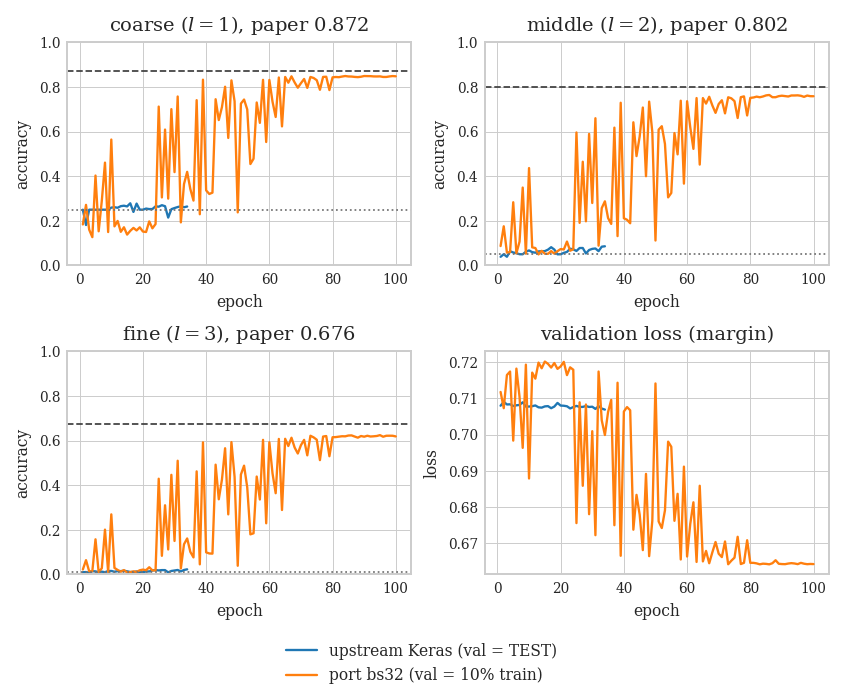

| Upstream Keras run | |
|---|---|
| epochs logged | 34 / 200 |
| latest val accuracy | 0.2642 / 0.0860 / 0.0230 |
| latest val loss | 0.7069 |
| latest train fine accuracy | 0.0197 |
| first epoch with fine > 2x floor | 31 |

In [44]:
import csv
import json as _json
from pathlib import Path

import matplotlib.pyplot as plt

# Edit these if the reproduction is re-run under a different tag or seed.
REPRO_DIR = Path('/scratch/g.saggini1/outputs/htcapsnet_repro_keep')
KERAS_LOG = REPRO_DIR / 'paper_e200_b32_s42_partial_log.csv'
LOCAL_RUNS = [
    ('port bs32 (val = 10% train)', '/scratch/g.saggini1/outputs/capsnet_cifar100/seed_0/run_log.jsonl'),
    ('port bs256 (val = 10% train)', '/scratch/g.saggini1/outputs/capsnet_cifar100_bs256/seed_0/run_log.jsonl'),
]
PAPER_TABLE = (0.8717, 0.8022, 0.6758)   # CIFAR-100, independent per-level accuracy
CONSTANT_FLOOR = (0.25, 0.05, 0.01)      # majority-class rate at 8 / 20 / 100 classes
LEVEL_KEYS = ('coarse1', 'coarse2', 'fine')


def read_keras_log(path):
    """Epoch -> (acc coarse1, acc coarse2, acc fine, val loss, train fine acc)."""
    out = {}
    if not Path(path).exists():
        return out
    with open(path) as handle:
        for row in csv.DictReader(handle):
            try:
                # Keras logs the epoch 0-indexed; the local runs count from 1.
                out[int(row['epoch']) + 1] = (
                    float(row['val_Out_L_0_accuracy']),
                    float(row['val_Out_L_1_accuracy']),
                    float(row['val_Out_L_2_accuracy']),
                    float(row['val_loss']),
                    float(row['Out_L_2_accuracy']),
                )
            except (KeyError, ValueError):
                continue
    return out


def read_local_log(path):
    out = {}
    if not Path(path).exists():
        return out
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            try:
                record = _json.loads(line)
            except _json.JSONDecodeError:
                continue
            if 'epoch' not in record or 'val_metrics' not in record:
                continue
            metrics = record['val_metrics']
            losses = record.get('val_losses', {})
            out[int(record['epoch'])] = (
                metrics['acc_level_independent_0'],
                metrics['acc_level_independent_1'],
                metrics['acc_level_independent_2'],
                float(losses.get('total', float('nan'))),
                float('nan'),
            )
    return out


def plot_keras_reproduction(max_epoch=None):
    """Set `max_epoch` to zoom on the early epochs while the run is short."""
    keras_curve = read_keras_log(KERAS_LOG)
    if not keras_curve:
        print(f'No upstream log yet at {KERAS_LOG}')
        return
    local_curves = [(label, read_local_log(path)) for label, path in LOCAL_RUNS]

    thesis_style.use_paper_style()
    fig, axes = plt.subplots(
        2, 2,
        figsize=(
            thesis_style.TEXT_WIDTH_IN,
            2 * thesis_style.PANEL_HEIGHT_2COL_IN + thesis_style.legend_height_in(3),
        ),
    )
    series = [('upstream Keras (val = TEST)', keras_curve), *local_curves]

    for level in range(3):
        ax = axes.flat[level]
        for label, curve in series:
            if not curve:
                continue
            epochs = sorted(curve)
            ax.plot(epochs, [curve[e][level] for e in epochs], label=label, linewidth=1.2)
        ax.axhline(CONSTANT_FLOOR[level], linestyle=':', color='0.45', linewidth=0.9)
        ax.axhline(PAPER_TABLE[level], linestyle='--', color='0.25', linewidth=0.9)
        ax.set_title(
            f'{thesis_style.level_display_name(LEVEL_KEYS[level])} '
            f'({thesis_style.level_index_symbol(level)}), paper {PAPER_TABLE[level]:.3f}'
        )
        ax.set_xlabel('epoch')
        ax.set_ylabel('accuracy')
        ax.set_ylim(0.0, 1.0)
        if max_epoch:
            ax.set_xlim(0, max_epoch)

    ax = axes.flat[3]
    for label, curve in series:
        if not curve:
            continue
        epochs = sorted(curve)
        ax.plot(epochs, [curve[e][3] for e in epochs], label=label, linewidth=1.2)
    ax.set_title('validation loss (margin)')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    if max_epoch:
        ax.set_xlim(0, max_epoch)

    # Same bottom-legend convention as the shared sections: constrained layout is
    # on via PAPER_RCPARAMS, so the legend is placed outside rather than by
    # reserving space with tight_layout.
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside lower center', ncol=1, frameon=False)
    plt.show()

    last = max(keras_curve)
    coarse1, coarse2, fine, val_loss, train_fine = keras_curve[last]
    escaped = [e for e in sorted(keras_curve) if keras_curve[e][2] > 2 * CONSTANT_FLOOR[2]]
    rows = [
        f'| epochs logged | {last} / 200 |',
        f'| latest val accuracy | {coarse1:.4f} / {coarse2:.4f} / {fine:.4f} |',
        f'| latest val loss | {val_loss:.4f} |',
        f'| latest train fine accuracy | {train_fine:.4f} |',
        '| first epoch with fine > 2x floor | '
        + (f'{escaped[0]}' if escaped else 'not yet - still on the constant-output floor')
        + ' |',
    ]
    show_markdown('\n'.join(['| Upstream Keras run | |', '|---|---|', *rows]))


plot_keras_reproduction()


### mAP, as the paper defines it

The repository does not compute this metric anywhere, and the name it does carry is
misleading: `weighted_ap` in `train/metrics.py` is a class-count-weighted top-1
accuracy across levels, not an average precision. Upstream `src/metrics.py` computes,
per level, `sklearn.average_precision_score(y_onehot, scores)` at the default macro
average, then reports the harmonic mean (`Harmonic_mAP_Score`) and the arithmetic mean
(`Arithmetic_mAP_Score`) over the three levels. The two are not comparable, so the
table below reports the upstream definition on both sides.

`scores` are the `LengthLayer` outputs, i.e. softmax over capsule lengths at
evaluation time. The port exposes exactly that as `effective_probs_per_level`, so both
sides feed the same quantity to the same estimator.

The first row is the floor, and it is forced rather than measured. Under a
constant-output solution every sample carries the same score vector, so within a class
column all samples tie: the precision-recall curve collapses to the single point
(recall 1, precision = prevalence), `AP_c = prevalence_c`, and the macro average is
exactly `1/C`. That gives 0.125 / 0.05 / 0.01 at the 8/20/100 levels, a harmonic mAP of
0.0234 and an arithmetic mAP of 0.0617, confirmed against the real CIFAR-100 test
labels by `chance_map.py`. A run in margin collapse cannot score above that, whatever
else is true of it.

Set `PAPER_MAP` once the value is read off the paper's CIFAR-100 figure; until then the
row prints as unknown rather than guessing.

In [45]:
MAP_SCORES = REPRO_DIR / 'map_scores.json'
# `performance_metrics.csv` is written only after training finishes, so the 200-epoch
# run stopped at epoch 34 has none. The 2-epoch smoke run does, and it is the
# measurement that matters: what the released readout scores while still on the floor.
KERAS_PERF = REPRO_DIR / 'smoke_e2_performance_metrics.csv'

# Harmonic and arithmetic mAP as printed in the paper's CIFAR-100 figure.
# Left as None deliberately: no value is invented here.
PAPER_MAP = {'harmonic': None, 'arithmetic': None}


def show_map_table():
    rows = []

    def add(label, harmonic, arithmetic, per_level=None):
        def cell(value):
            return f'{value:.4f}' if isinstance(value, float) else 'unknown'
        levels = ' / '.join(f'{v:.4f}' for v in per_level) if per_level else '--'
        rows.append(f'| {label} | {levels} | {cell(harmonic)} | {cell(arithmetic)} |')

    add('paper, CIFAR-100 figure', PAPER_MAP['harmonic'], PAPER_MAP['arithmetic'])

    if KERAS_PERF.exists():
        values = {}
        with open(KERAS_PERF) as handle:
            for row in csv.reader(handle):
                if len(row) == 2:
                    values[row[0]] = row[1]
        try:
            add('upstream Keras, epoch 2 (released layernorm readout)',
                float(values['Harmonic_mAP_Score']), float(values['Arithmetic_mAP_Score']))
        except (KeyError, ValueError):
            add('upstream Keras, epoch 2 (released layernorm readout)', None, None)
    else:
        add('upstream Keras (no test evaluation on disk)', None, None)

    if MAP_SCORES.exists():
        cached = _json.loads(MAP_SCORES.read_text())
        for label, entry in cached['runs'].items():
            if label.startswith('upstream Keras'):
                continue  # already added above, from the csv
            add(label, entry['harmonic'], entry['arithmetic'], entry.get('per_level'))

    header = ['| Source | per-level mAP (coarse / middle / fine) | harmonic mAP | arithmetic mAP |',
              '|---|---|---:|---:|']
    show_markdown('\n'.join([*header, *rows]))


show_map_table()


| Source | per-level mAP (coarse / middle / fine) | harmonic mAP | arithmetic mAP |
|---|---|---:|---:|
| paper, CIFAR-100 figure | -- | unknown | unknown |
| upstream Keras, epoch 2 (released layernorm readout) | -- | 0.0254 | 0.0668 |
| constant-output floor (margin collapse, analytic = 1/C per level) | 0.1250 / 0.0500 / 0.0100 | 0.0234 | 0.0617 |
| port bs256 (independent ckpt, epoch 97 of 100) | 0.7933 / 0.6435 / 0.4586 | 0.6006 | 0.6318 |
| port bs32 (independent ckpt, epoch 32 of 35) | 0.3697 / 0.1927 / 0.0551 | 0.1151 | 0.2058 |